# Loan Default Prediction: GDG OAU / Zindi Challenge

Predicts the probability that a customer defaults on a loan (`target` = 1)
vs. repays (`target` = 0), using Kenyan lending data + World Bank-style
economic indicators.


## 1. Setup & imports

In [43]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import xgboost as xgb

pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load the data

In [44]:
DIR = r"C:\Users\HP\Downloads\african-credit-scoring-challenge20241203-14702-1yayxml"

train = pd.read_csv(f"{DIR}/Train.csv")
test = pd.read_csv(f"{DIR}/Test.csv")
econ = pd.read_csv(f"{DIR}/economic_indicators.csv")
sample_submission = pd.read_csv(f"{DIR}/SampleSubmission.csv")


print(f"Train: {train.shape[0]} rows, {train.shape[1]} cols")
print(f"Test : {test.shape[0]} rows, {test.shape[1]} cols")
print(f"Econ : {econ.shape[0]} rows, {econ.shape[1]} cols")
print(f"Sample : {sample_submission.shape[0]} rows, {sample_submission.shape[1]} cols")

Train: 68654 rows, 16 cols
Test : 18594 rows, 15 cols
Econ : 27 rows, 25 cols
Sample : 18594 rows, 2 cols


In [45]:
train.head()

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


In [46]:
econ.head()

,Country,Indicator,YR2001,YR2002,YR2003,YR2004,YR2005,YR2006,YR2007,YR2008,YR2009,YR2010,YR2011,YR2012,YR2013,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023
0,Ghana,"Inflation, consumer prices (annual %)",41.509496,9.360932,29.772980,18.042739,15.438992,11.679184,10.734267,16.494640,19.246948,10.733390,8.728459,11.186341,11.666192,15.489616,17.149970,17.454635,12.371922,7.808765,7.143640,9.887290,9.971089,31.255895,38.106966
1,Cote d'Ivoire,"Inflation, consumer prices (annual %)",4.361529,3.077265,3.296807,1.457988,3.885830,2.467191,1.892006,6.308528,1.019505,1.226456,4.912434,1.304511,2.581170,0.448682,1.251500,0.723178,0.685881,0.359409,-1.106863,2.425007,4.091952,5.276167,4.387117
2,Kenya,"Inflation, consumer prices (annual %)",5.738598,1.961308,9.815691,11.624036,10.312778,14.453734,9.758880,26.239817,9.234126,3.961389,14.022491,9.377770,5.717494,6.878155,6.582154,6.297250,8.005650,4.689806,5.239638,5.405162,6.107936,7.659863,7.671396
3,Ghana,"Official exchange rate (LCU per US$, period av...",0.716305,0.792417,0.866764,0.899495,0.905209,0.915107,0.932619,1.052275,1.404967,1.429983,1.520625,1.824867,1.981350,2.896575,3.714642,3.909817,4.350533,4.585325,5.217367,5.595708,5.805700,8.272400,11.020408
4,Cote d'Ivoire,"Official exchange rate (LCU per US$, period av...",732.397693,693.713226,579.897426,527.338032,527.258363,522.425625,478.633718,446.000041,470.293423,494.794262,471.248626,510.556338,493.899624,493.757330,591.211698,592.605615,580.656750,555.446458,585.911013,575.586005,554.530675,623.759701,606.569750


## 3. Exploratory Data Analysis

Before touching any model, understanding what's actually driving default risk in this data. This shapes every feature-engineering and model building

In [47]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68654 entries, 0 to 68653
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           68654 non-null  object 
 1   customer_id                  68654 non-null  int64  
 2   country_id                   68654 non-null  object 
 3   tbl_loan_id                  68654 non-null  int64  
 4   lender_id                    68654 non-null  int64  
 5   loan_type                    68654 non-null  object 
 6   Total_Amount                 68654 non-null  float64
 7   Total_Amount_to_Repay        68654 non-null  float64
 8   disbursement_date            68654 non-null  object 
 9   due_date                     68654 non-null  object 
 10  duration                     68654 non-null  int64  
 11  New_versus_Repeat            68654 non-null  object 
 12  Amount_Funded_By_Lender      68654 non-null  float64
 13  Lender_portion_F

In [48]:
train.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
customer_id,68654.0,254390.257,26642.720,145.0,248945.750,255361.0,262269.25,3.127370e+05
tbl_loan_id,68654.0,263056.266,39486.661,101323.0,233942.250,260305.5,286962.75,3.753200e+05
lender_id,68654.0,266420.528,3590.999,245684.0,267278.000,267278.0,267278.00,2.672780e+05
Total_Amount,68654.0,14836.829,141649.868,2.0,2295.000,5249.0,11450.00,2.300000e+07
Total_Amount_to_Repay,68654.0,15639.930,165078.353,0.0,2329.000,5325.0,11650.00,2.541500e+07
duration,68654.0,8.545,13.343,1.0,7.000,7.0,7.00,1.096000e+03
Amount_Funded_By_Lender,68654.0,2545.663,11922.724,0.0,234.000,915.0,2272.65,1.600000e+06
Lender_portion_Funded,68654.0,0.219,0.130,0.0,0.119,0.3,0.30,1.168000e+00
Lender_portion_to_be_repaid,68654.0,2652.621,13380.064,0.0,239.000,934.0,2317.00,1.821338e+06
target,68654.0,0.018,0.134,0.0,0.000,0.0,0.00,1.000000e+00


In [49]:
def to_datetime_cols(df, cols, fmt=None, errors='coerce'):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], format=fmt, errors=errors)
    return df

date_cols = ['disbursement_date', 'due_date']
train = to_datetime_cols(train, date_cols)
test = to_datetime_cols(test, date_cols)

if 'target' in train.columns:
    train['target'] = train['target'].astype('Int64')


In [50]:
missing = pd.DataFrame({
    'Missing': train.isnull().sum(),
    '% Missing': (train.isnull().sum() / len(train) * 100).round(2),
    'Not Missing': train.notnull().sum(),
}).sort_values('% Missing', ascending=False)

print('=' * 90)
print(f'{"Feature":<35} {"Missing":>12} {"% Missing":>12} {"Not Missing":>12} ')
print('=' * 90)
for idx, row in missing.iterrows():
    print(f"{idx:<35} {row['Missing']:>12,} {row['% Missing']:>11.1f}% {row['Not Missing']:>11.1f} ")
print('=' * 90)

Feature                                  Missing    % Missing  Not Missing 
ID                                           0.0         0.0%     68654.0 
customer_id                                  0.0         0.0%     68654.0 
country_id                                   0.0         0.0%     68654.0 
tbl_loan_id                                  0.0         0.0%     68654.0 
lender_id                                    0.0         0.0%     68654.0 
loan_type                                    0.0         0.0%     68654.0 
Total_Amount                                 0.0         0.0%     68654.0 
Total_Amount_to_Repay                        0.0         0.0%     68654.0 
disbursement_date                            0.0         0.0%     68654.0 
due_date                                     0.0         0.0%     68654.0 
duration                                     0.0         0.0%     68654.0 
New_versus_Repeat                            0.0         0.0%     68654.0 
Amount_Funded_By_Lender 

**No missing values**

Target balance:
target
0    0.981676
1    0.018324
Name: proportion, dtype: Float64


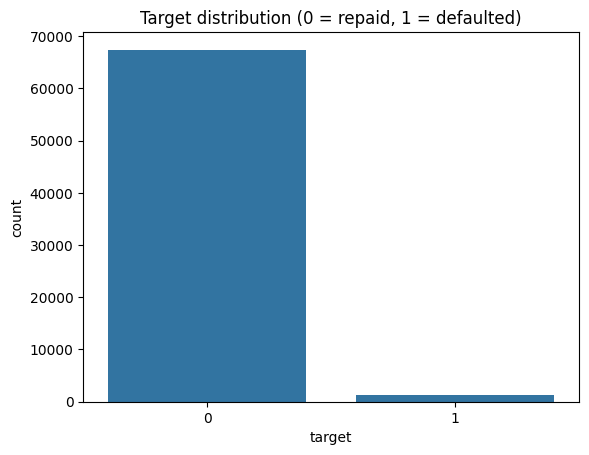

In [51]:
print("Target balance:")
print(train["target"].value_counts(normalize=True))
sns.countplot(x="target", data=train)
plt.title("Target distribution (0 = repaid, 1 = defaulted)")
plt.show()


In [52]:
print("Countries in loan data:", train["country_id"].unique())
print("Countries in economic indicators:", econ["Country"].unique())
print("Loan types:", train["loan_type"].nunique())
print("Lenders:", train["lender_id"].nunique())
n_overlap = len(set(train["customer_id"]) & set(test["customer_id"]))
print(f"Customers in both train & test: {n_overlap} / {test['customer_id'].nunique()} test customers")


Countries in loan data: ['Kenya']
Countries in economic indicators: ['Ghana' "Cote d'Ivoire" 'Kenya']
Loan types: 22
Lenders: 4
Customers in both train & test: 4306 / 4962 test customers


In [53]:
def default_rate_table(df, col, min_count=1):
    t = df.groupby(col)["target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    return t[t["count"] >= min_count]

print('Loan defaulting rate by loan type')
print(default_rate_table(train, "loan_type"))


Loan defaulting rate by loan type
               mean  count
loan_type                 
Type_15        0.75      4
Type_23    0.722222     18
Type_14    0.717172     99
Type_2     0.608108     74
Type_20    0.538462     13
Type_9      0.17561    205
Type_4     0.123077   1235
Type_6     0.106443    357
Type_7     0.084229   2790
Type_5      0.08021   1521
Type_12    0.047619     21
Type_11    0.047619     42
Type_18    0.033333     30
Type_10    0.025751    466
Type_1     0.008425  61723
Type_13         0.0     10
Type_16         0.0     12
Type_17         0.0     23
Type_19         0.0      4
Type_21         0.0      3
Type_22         0.0      1
Type_24         0.0      3


Massive signal here: **`Type_1` loans almost covers all loans and defaults only 0.8% of the time**, while rarer loan types (`Type_15`, `Type_23`,
`Type_14`, `Type_2`...) default 50–75% of the time. `loan_type` alone is going to be one of the strongest predictors.

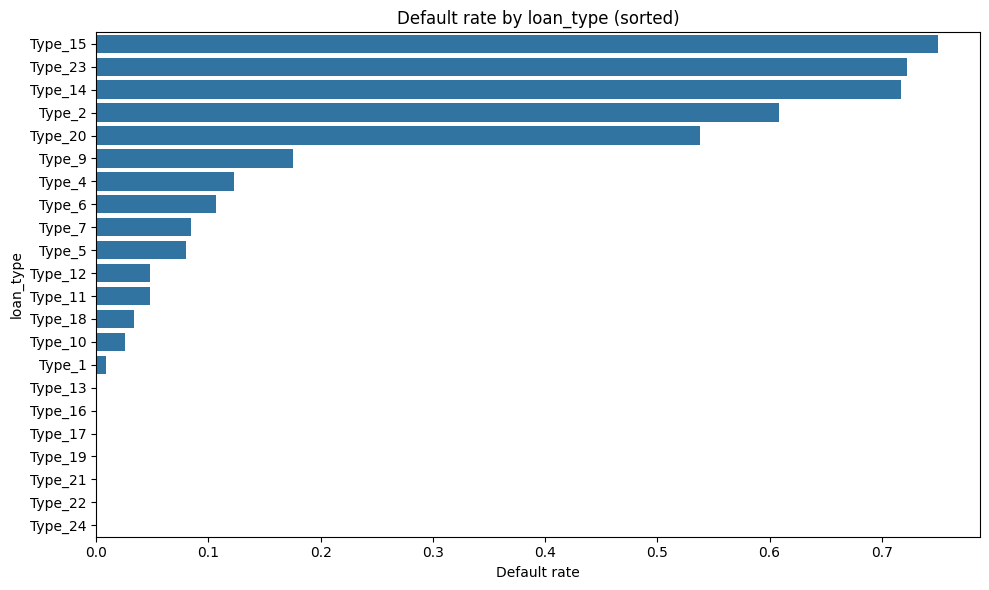

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
lt = default_rate_table(train, "loan_type")
sns.barplot(x=lt["mean"], y=lt.index, ax=ax)
ax.set_xlabel("Default rate")
ax.set_title("Default rate by loan_type (sorted)")
plt.tight_layout()
plt.show()


In [55]:
print('Defaulting rate by lender_id')
print(default_rate_table(train, "lender_id"))
print()
print('Defaulting rate by New_versus_Repeat loans')
print(default_rate_table(train, "New_versus_Repeat"))


Defaulting rate by lender_id
               mean  count
lender_id                 
245684     0.414894    188
267277     0.295203    271
251804     0.089215   3542
267278     0.012126  64653

Defaulting rate by New_versus_Repeat loans
                       mean  count
New_versus_Repeat                 
New Loan           0.209877    567
Repeat Loan        0.016729  68087


Similarly strong signals:
- **Lender `267278` funds 94% of loans at a 1.2% default rate**, while two
  small lenders (`245684`, `267277`) run default rates of 30–41%.
- **New loans default 21% of the time vs. 1.7% for repeat loans** a first-time
  borrower is roughly 12x riskier than a returning one. This is exactly why
  the customer-history features (prior loan count, prior default rate)

In [56]:
train["year"] = train["disbursement_date"].dt.year
test["disbursement_date_tmp"] = pd.to_datetime(test["disbursement_date"])
test["year_tmp"] = test["disbursement_date_tmp"].dt.year

print("Train loans per year:")
print(train["year"].value_counts().sort_index())
print("\nDefault rate per year (train):")
print(train.groupby("year")["target"].mean())
print("\nTest loans per year:")
print(test["year_tmp"].value_counts().sort_index())

test = test.drop(columns=["disbursement_date_tmp", "year_tmp"])


Train loans per year:
year
2021       39
2022    64405
2023     1240
2024     2970
Name: count, dtype: int64

Default rate per year (train):
year
2021    0.538462
2022     0.01298
2023    0.115323
2024    0.086869
Name: target, dtype: Float64

Test loans per year:
year_tmp
2021.0       28
2022.0    17248
2023.0      688
2024.0      629
Name: count, dtype: int64


**Volume is heavily concentrated in 2022** (94% of train rows), with a tiny, anomalous 2021 slice (39 loans, 54% default) and smaller 2023–2024 slices that run *higher* default rates (11.5%,8.7%) than 2022's 1.3%. Test has the same skew toward 2022.

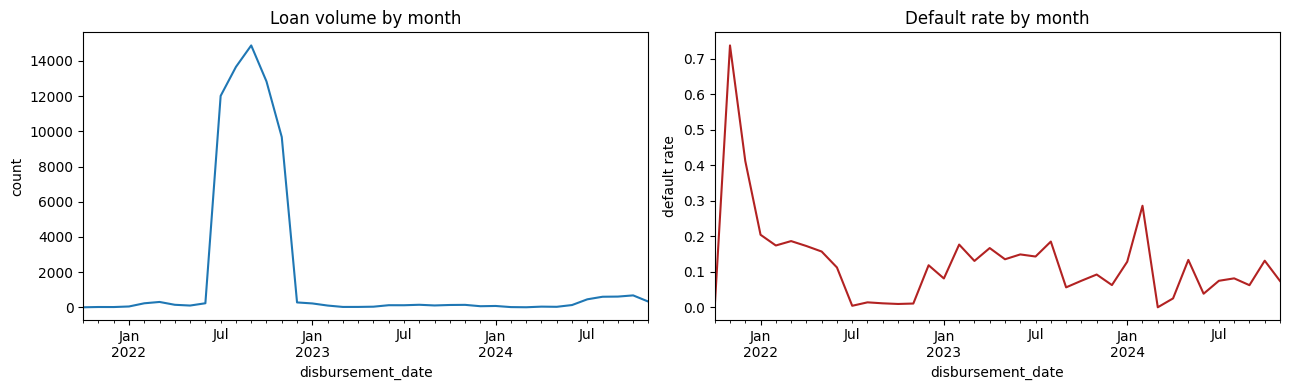

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train.groupby(train["disbursement_date"].dt.to_period("M")).size().plot(ax=axes[0])
axes[0].set_title("Loan volume by month")
axes[0].set_ylabel("count")

train.groupby(train["disbursement_date"].dt.to_period("M"))["target"].mean().plot(ax=axes[1], color="firebrick")
axes[1].set_title("Default rate by month")
axes[1].set_ylabel("default rate")
plt.tight_layout()
plt.show()


In [58]:
print(train["Total_Amount"].describe())
print()
print("Loans with Total_Amount > 1,000,000:", (train['Total_Amount'] > 1_000_000).sum(), "/", len(train))
print(train.loc[train['Total_Amount'] > 1_000_000, 'target'].mean(), "default rate among them")


count    6.865400e+04
mean     1.483683e+04
std      1.416499e+05
min      2.000000e+00
25%      2.295000e+03
50%      5.249000e+03
75%      1.145000e+04
max      2.300000e+07
Name: Total_Amount, dtype: float64

Loans with Total_Amount > 1,000,000: 48 / 68654
0.4791666666666667 default rate among them


`Total_Amount` is extremely right-skewed (with a median ~5250, min of 2 but a max of
23,000,000) having 48 loans of very large loans existing in the dataset, and they default at **48%**, far above the 1.8% baseline. A log scaling is used to see distribution and let tree models XGBOOST handle the skewness internally

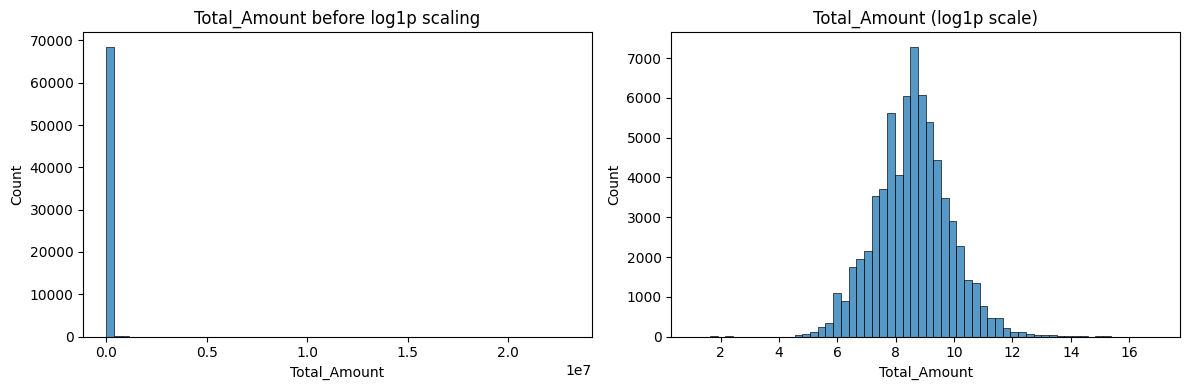

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["Total_Amount"], bins=60, ax=axes[0])
axes[0].set_title("Total_Amount before log1p scaling")

sns.histplot(np.log1p(train["Total_Amount"]), bins=60, ax=axes[1])
axes[1].set_title("Total_Amount (log1p scale)")
plt.tight_layout()
plt.show()


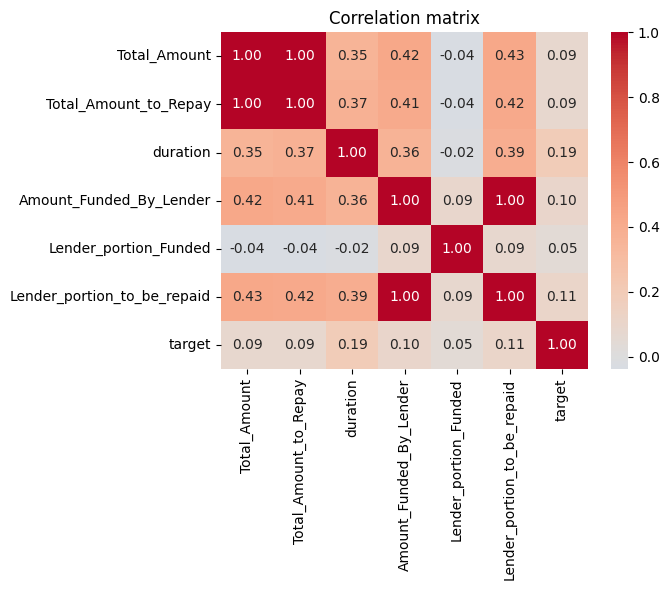

target                         1.000000
duration                       0.189889
Lender_portion_to_be_repaid    0.109517
Amount_Funded_By_Lender        0.101845
Total_Amount_to_Repay          0.087089
Total_Amount                   0.086043
Lender_portion_Funded          0.045418
Name: target, dtype: float64

In [60]:
num_cols = ["Total_Amount", "Total_Amount_to_Repay", "duration",
            "Amount_Funded_By_Lender", "Lender_portion_Funded",
            "Lender_portion_to_be_repaid", "target"]
corr = train[num_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

corr["target"].sort_values(ascending=False)


Raw numeric fields only correlate weakly with `target` individually
(`duration` is the strongest at ~0.19)

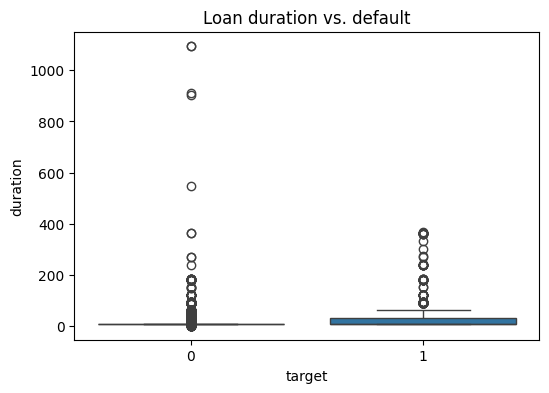

          count       mean        std  min  25%  50%   75%     max
target                                                            
0       67396.0   8.198424  11.206779  1.0  7.0  7.0   7.0  1096.0
1        1258.0  27.089825  51.376803  7.0  7.0  7.0  30.0   366.0


In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="target", y="duration", data=train, ax=ax)
ax.set_title("Loan duration vs. default")
plt.show()

print(train.groupby("target")["duration"].describe())


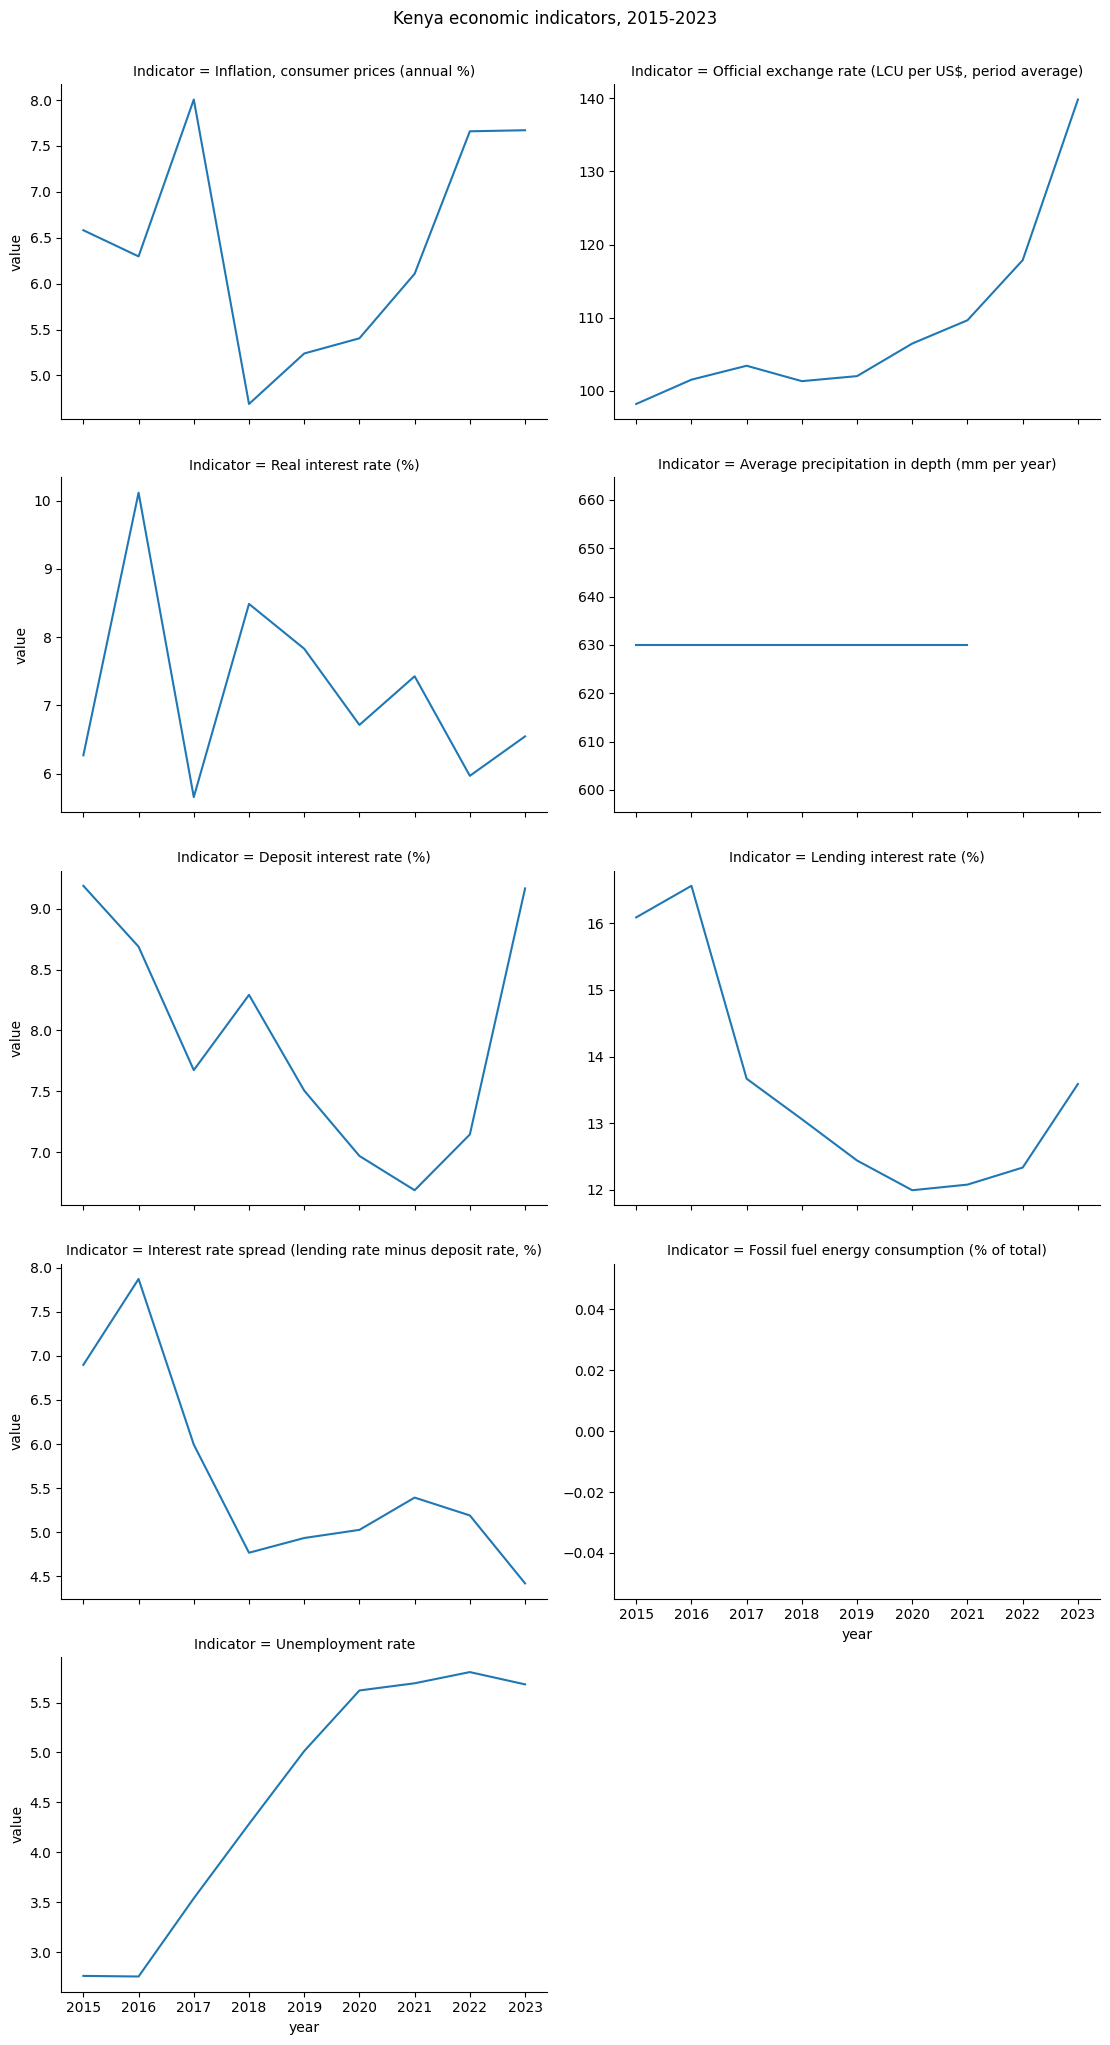

In [62]:
econ_kenya = econ[econ["Country"] == "Kenya"]
year_cols_preview = [c for c in econ.columns if c.startswith("YR")]
econ_kenya_long = econ_kenya.melt(id_vars=["Indicator"], value_vars=year_cols_preview,
                                   var_name="year", value_name="value")
econ_kenya_long["year"] = econ_kenya_long["year"].str.replace("YR", "").astype(int)
econ_kenya_long = econ_kenya_long[econ_kenya_long["year"] >= 2015]

g = sns.relplot(data=econ_kenya_long, x="year", y="value", col="Indicator",
                 col_wrap=2, kind="line", height=4, aspect=1.4, facet_kws={"sharey": False})
g.fig.suptitle("Kenya economic indicators, 2015-2023", y=1.02)
plt.show()


## 4. Combine train + test for consistent feature engineering

In [63]:
target_col = "target"
train["is_train"] = 1
test["is_train"] = 0
test[target_col] = np.nan

full = pd.concat([train, test], axis=0, ignore_index=True, sort=False)
full['disbursement_date'] = pd.to_datetime(full['disbursement_date'], errors="coerce")
full['due_date'] = pd.to_datetime(full["due_date"], errors="coerce")
full['disbursement_year'] = full['disbursement_date'].dt.year

print(full.shape)


(87248, 19)


In [67]:
max_disb_date = full.groupby("customer_id")["disbursement_date"].transform("max")
full["is_relevant"] = (full["due_date"] >= max_disb_date).astype(int)

print(f'Overall: {full["is_relevant"].sum()} / {len(full)} rows flagged as relevant or needed')


train_mask = full["is_train"] == 1
print()
print('TRAIN DATA:')
print(f'Default rate overall:{full.loc[train_mask, target_col].mean():.4f}')
print(f"Default rate where is_relevant==1: {full.loc[train_mask & (full['is_relevant']==1), target_col].mean():.4f}  (n={ (train_mask & (full['is_relevant']==1)).sum() })")
print(f"Default rate where is_relevant== 0: {full.loc[train_mask & (full['is_relevant']==0), target_col].mean():.4f}  (n={ (train_mask & (full['is_relevant']==0)).sum() })")

total_defaults = full.loc[train_mask, target_col].sum()
captured = full.loc[train_mask & (full['is_relevant']==1), target_col].sum()
print(f'\nFraction of ALL train defaults captured within is_relevant==1: {captured/total_defaults:.4f}')


Overall: 13005 / 87248 rows flagged as relevant or needed

TRAIN DATA:
Default rate overall:0.0183
Default rate where is_relevant==1: 0.1196  (n=9973)
Default rate where is_relevant== 0: 0.0011  (n=58681)

Fraction of ALL train defaults captured within is_relevant==1: 0.9483


On the real data, **~95% of all defaults live inside the ~15% of rows flagged `is_relevant`** the non-relevant subset has an almost-zero (~0.1%) default rate. This is a genuinely useful signal, not leakage: it's built purely from `disbursement_date`/`due_date`, which are known at prediction time for every row (including all of test).

In [ ]:
ghana_test = full[(full["is_train"] == 0) & (full["country_id"] == "Ghana")]
kenya_test = full[(full["is_train"] == 0) & (full["country_id"] == "Kenya")]
print('Test rows by country:', full.loc[full['is_train']==0, 'country_id'].value_counts().to_dict())
print('Train countries:', full.loc[full['is_train']==1, 'country_id'].unique())
print()
print('Ghana lenders never seen in train:', set(ghana_test['lender_id']) - set(train['lender_id']))
print('Ghana loan_types never seen in train:', set(ghana_test['loan_type']) - set(train['loan_type']))
print('Ghana customers seen in train:', len(set(ghana_test['customer_id']) & set(train['customer_id'])))


Test rows by country: {'Kenya': 15069, 'Ghana': 3525}
Train countries: ['Kenya']

Ghana lenders never seen in train: {'296540', '297183', '297182', '245684', '296542'}
Ghana loan_types never seen in train: {'Type_3', 'Type_8'}
Ghana customers seen in train: 0


**Ghana is a genuine out-of-distribution problem, confirmed in the data:**
test contains 3,525 Ghanaian loans (~19% of test) but *train has zero
Ghanaian rows*. Ghana also brings lender IDs and loan types the model has
never seen a single training example of, and zero customer overlap so
customer-history features are uninformative there too.

## 5. Reshape & merge economic indicators

In [40]:
year_cols = [c for c in econ.columns if c.startswith("YR")]
econ_long = econ.melt(id_vars=["Country", "Indicator"], value_vars=year_cols,
                       var_name="year_str", value_name="value")
econ_long["year"] = econ_long["year_str"].str.replace("YR", "").astype(int)

econ_wide = econ_long.pivot_table(index=["Country", "year"], columns="Indicator", values="value").reset_index()
econ_wide.columns.name = None
print("Reshaped economic indicators:", econ_wide.shape)

max_econ_year = econ_wide["year"].max()
full["econ_join_year"] = full["disbursement_year"].clip(upper=max_econ_year)

full = full.merge(econ_wide, left_on=["country_id", "econ_join_year"], right_on=["Country", "year"], how="left")
econ_indicator_cols = [c for c in econ_wide.columns if c not in ("Country", "year")]
print("Missing rate on merged economic columns:", full[econ_indicator_cols].isna().mean().mean().round(3))
print(full.shape)


Reshaped economic indicators: (69, 11)
Missing rate on merged economic columns: 0.236
(87248, 63)


## 6. Feature engineering

In [68]:
full["disb_month"] = full["disbursement_date"].dt.month
full["disb_dayofweek"] = full["disbursement_date"].dt.dayofweek
full["disb_quarter"] = full["disbursement_date"].dt.quarter
full["days_to_due"] = (full["due_date"] - full["disbursement_date"]).dt.days

full["repay_to_principal_ratio"] = full["Total_Amount_to_Repay"] / full["Total_Amount"].replace(0, np.nan)
full["interest_amount"] = full["Total_Amount_to_Repay"] - full["Total_Amount"]
full["interest_rate_implied"] = full["interest_amount"] / full["Total_Amount"].replace(0, np.nan)
full["interest_rate_per_day"] = full["interest_rate_implied"] / full["duration"].replace(0, np.nan)
full["lender_funding_ratio"] = full["Amount_Funded_By_Lender"] / full["Total_Amount"].replace(0, np.nan)

print("Shape:", full.shape)


Shape: (87248, 29)


In [ ]:

full = full.sort_values(["customer_id", "disbursement_date"]).reset_index(drop=True)
grp = full.groupby("customer_id")

full["cust_prior_loan_count"] = grp.cumcount()
full["cust_prior_amount_mean"] = grp["Total_Amount"].transform(lambda s: s.shift(1).expanding().mean())
full["cust_prior_amount_std"] = grp["Total_Amount"].transform(lambda s: s.shift(1).expanding().std())
#expanding().mean()/.sum() automatically skip the NaN

full["cust_prior_default_rate"] = grp[target_col].transform(lambda s: s.shift(1).expanding().mean())
full["cust_prior_default_count"] = grp[target_col].transform(lambda s: s.shift(1).expanding().sum())


In [70]:
#CAT encoding for categorical columns
cat_cols = [c for c in ["loan_type", "lender_id", "New_versus_Repeat"] if c in full.columns]
print("Categorical columns:", cat_cols)

for c in cat_cols:
    full[c] = full[c].astype(str)
    freq = full[c].value_counts(normalize=True)
    full[f"{c}_freq"] = full[c].map(freq)
    le = LabelEncoder()
    full[f"{c}_le"] = le.fit_transform(full[c])

full.head()


Categorical columns: ['loan_type', 'lender_id', 'New_versus_Repeat']


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year,is_train,disbursement_year,is_relevant,disb_month,disb_dayofweek,disb_quarter,days_to_due,repay_to_principal_ratio,interest_amount,interest_rate_implied,interest_rate_per_day,lender_funding_ratio,cust_prior_loan_count,cust_prior_amount_mean,cust_prior_amount_std,cust_prior_default_rate,cust_prior_default_count,loan_type_freq,loan_type_le,lender_id_freq,lender_id_le,New_versus_Repeat_freq,New_versus_Repeat_le
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0,2022.0,1,2022.0,1,3.0,2.0,1.0,30.0,1.085379,1238.0,0.085379,0.002846,0.689655,0,NaN,NaN,NaN,NaN,0.000642,2,0.003954,0,0.991564,1
1,ID_161361065267277,161,Kenya,361065,267277,Type_9,11025.0,11686.5,2024-01-15,2024-02-14,30,Repeat Loan,4097.0,0.371610,4343.0,0,2024.0,1,2024.0,1,1.0,0.0,1.0,30.0,1.060000,661.5,0.060000,0.002000,0.371610,0,NaN,NaN,NaN,NaN,0.002831,23,0.003633,2,0.991564,1
2,ID_166124634245684,166,Kenya,124634,245684,Type_11,5881.0,6914.0,2022-03-11,2022-04-10,30,Repeat Loan,5881.0,1.000000,6914.0,0,2022.0,1,2022.0,1,3.0,4.0,1.0,30.0,1.175650,1033.0,0.175650,0.005855,1.000000,0,NaN,NaN,NaN,NaN,0.000642,2,0.003954,0,0.991564,1
3,ID_1487125800245684,1487,Kenya,125800,245684,Type_11,7000.0,7850.0,2022-03-14,2022-04-13,30,Repeat Loan,7000.0,1.000000,7850.0,0,2022.0,1,2022.0,1,3.0,0.0,1.0,30.0,1.121429,850.0,0.121429,0.004048,1.000000,0,NaN,NaN,NaN,NaN,0.000642,2,0.003954,0,0.991564,1
4,ID_4534122904245684,4534,Kenya,122904,245684,Type_11,9565.0,10672.0,2022-03-07,2022-04-06,30,Repeat Loan,9565.0,1.000000,10672.0,0,2022.0,1,2022.0,0,3.0,0.0,1.0,30.0,1.115734,1107.0,0.115734,0.003858,1.000000,0,NaN,NaN,NaN,NaN,0.000642,2,0.003954,0,0.991564,1


In [71]:
drop_cols = {
    "ID", "customer_id", "tbl_loan_id", "target", "is_train", "is_relevant",
    "disbursement_date", "due_date", "country_id", "Country",
    "year_str", "econ_join_year", "year",
}
drop_cols |= set(cat_cols)

feature_cols = [c for c in full.columns if c not in drop_cols]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(full[c])]

#Cleaning the column names for LIGHTGBM
def clean_econ_name(c):
    return re.sub(r"[^0-9a-zA-Z_]+", "_", c)

rename_map = {c: clean_econ_name(c) for c in feature_cols}
full = full.rename(columns=rename_map)
feature_cols = [rename_map[c] for c in feature_cols]

print(f"Using {len(feature_cols)} features:")
print(feature_cols)


Using 27 features:
['Total_Amount', 'Total_Amount_to_Repay', 'duration', 'Amount_Funded_By_Lender', 'Lender_portion_Funded', 'Lender_portion_to_be_repaid', 'disbursement_year', 'disb_month', 'disb_dayofweek', 'disb_quarter', 'days_to_due', 'repay_to_principal_ratio', 'interest_amount', 'interest_rate_implied', 'interest_rate_per_day', 'lender_funding_ratio', 'cust_prior_loan_count', 'cust_prior_amount_mean', 'cust_prior_amount_std', 'cust_prior_default_rate', 'cust_prior_default_count', 'loan_type_freq', 'loan_type_le', 'lender_id_freq', 'lender_id_le', 'New_versus_Repeat_freq', 'New_versus_Repeat_le']


### Train on the `is_relevant` subset, but always predict the full test set

`train_fe` and `test_fe` below keep their **original row counts** (68,654
and 18,594) to never drop rows from either. `X`/`y` (what the models
actually train on) are restricted to `is_relevant == 1` training rows only,
which is where the model's inference actually goes to work. `X_test`
stays at the full 18,594 rows so every prediction array we build downstream
is automatically aligned with the sample submission file

In [72]:
# Restricting the data for only relvant stuff
train_fe = full[full["is_train"] == 1].copy()
test_fe = full[full["is_train"] == 0].copy()

relevant_train_mask = train_fe["is_relevant"] == 1
relevant_test_mask = (test_fe["is_relevant"] == 1).values  

X = train_fe.loc[relevant_train_mask, feature_cols]
y = train_fe.loc[relevant_train_mask, target_col].astype(int)
X_test = test_fe[feature_cols] 

print("Full train_fe / test_fe shapes:", train_fe.shape, test_fe.shape)
print("Relevant-subset training shape:", X.shape, "| positive rate:", y.mean().round(4))
print("Relevant test rows (will get a real model prediction):", relevant_test_mask.sum(), "/", len(test_fe))


Full train_fe / test_fe shapes: (68654, 40) (18594, 40)
Relevant-subset training shape: (9973, 27) | positive rate: 0.1196
Relevant test rows (will get a real model prediction): 3032 / 18594


## 8. Cross-validated training: LightGBM + XGBoost

5-fold stratified CV, trained only on the `is_relevant == 1` training rows (positive rate ~12% there, much more workable than the raw ~1.8%). Both models still use `scale_pos_weight` on top of that for extra robustness.

Test predictions are computed for **all 18,594 test rows** every fold (so the arrays never change length), then we hard-override any `is_relevant == 0` row to a 0 probability afterward those rows are non-defaults by construction.

In [73]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
test_pred_lgb = np.zeros(len(X_test))   
test_pred_xgb = np.zeros(len(X_test))

scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print("scale_pos_weight (within relevant subset):", scale_pos_weight)

lgb_params = dict(
    objective="binary", metric="auc", n_estimators=2000, learning_rate=0.03,
    num_leaves=63, min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
)

xgb_params = dict(
    objective="binary:logistic", eval_metric="auc", n_estimators=2000, learning_rate=0.03,
    max_depth=6, min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
)

last_lgb_model = None
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
    test_pred_lgb += model_lgb.predict_proba(X_test)[:, 1] / N_FOLDS 
    last_lgb_model = model_lgb

    model_xgb = xgb.XGBClassifier(**xgb_params, early_stopping_rounds=100)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    test_pred_xgb += model_xgb.predict_proba(X_test)[:, 1] / N_FOLDS

    print(f"Fold {fold + 1}/{N_FOLDS} — LGB AUC: {roc_auc_score(y_val, oof_lgb[val_idx]):.5f} | "
          f"XGB AUC: {roc_auc_score(y_val, oof_xgb[val_idx]):.5f}")

print("\nOOF AUC on the relevant-subset of the data ")
print("LightGBM:", roc_auc_score(y, oof_lgb))
print("XGBoost :", roc_auc_score(y, oof_xgb))


scale_pos_weight (within relevant subset): 7.359597652975691
Fold 1/5 — LGB AUC: 0.99503 | XGB AUC: 0.99442
Fold 2/5 — LGB AUC: 0.99536 | XGB AUC: 0.99506
Fold 3/5 — LGB AUC: 0.99333 | XGB AUC: 0.99315
Fold 4/5 — LGB AUC: 0.99652 | XGB AUC: 0.99613
Fold 5/5 — LGB AUC: 0.99512 | XGB AUC: 0.99435

OOF AUC on the relevant-subset of the data 
LightGBM: 0.9944845310629393
XGBoost : 0.9938519495844209


In [74]:
#Best data for predictions
best_w, best_auc = 0, 0
for w in np.arange(0, 1.01, 0.05):
    blend = w * oof_lgb + (1 - w) * oof_xgb
    auc = roc_auc_score(y, blend)
    if auc > best_auc:
        best_auc, best_w = auc, w

print(f"Best blend in models : {best_w:.2f} * LGB + {1 - best_w:.2f} * XGB -> relevant-subset OOF AUC = {best_auc:.5f}")

oof_blend = best_w * oof_lgb + (1 - best_w) * oof_xgb         
test_pred_blend_raw = best_w * test_pred_lgb + (1 - best_w) * test_pred_xgb 

#Force non relevant rows to be zero
test_pred_blend = np.where(relevant_test_mask, test_pred_blend_raw, 0.0)
print("Test predictions shape:", test_pred_blend.shape)


Best blend in models : 0.90 * LGB + 0.10 * XGB -> relevant-subset OOF AUC = 0.99455
Test predictions shape: (18594,)


In [76]:
oof_full = np.zeros(len(train_fe))
oof_full[relevant_train_mask.values] = oof_blend

y_full = train_fe[target_col].astype(int).values

print("Full-dataset OOF AUC (honest estimate):", roc_auc_score(y_full, oof_full))


Full-dataset OOF AUC (honest estimate): 0.9701265099399217


## 9. Feature importance

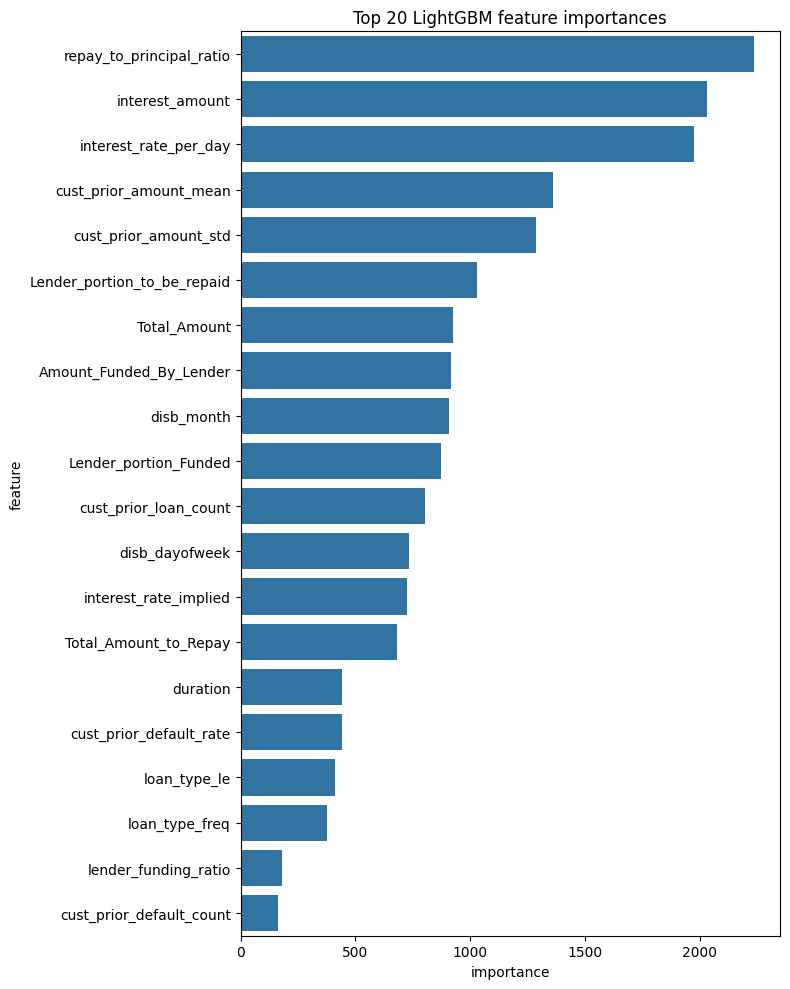

,feature,importance
11,repay_to_principal_ratio,2238
12,interest_amount,2033
14,interest_rate_per_day,1976
17,cust_prior_amount_mean,1359
18,cust_prior_amount_std,1288
5,Lender_portion_to_be_repaid,1030
0,Total_Amount,925
3,Amount_Funded_By_Lender,916
7,disb_month,908
4,Lender_portion_Funded,875


In [77]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": last_lgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(data=importances.head(20), x="importance", y="feature")
plt.title("Top 20 LightGBM feature importances")
plt.tight_layout()
plt.show()

importances.head(20)


## 10. Build the submission file

Matches `SampleSubmission.csv`'s `ID, target` structure, where `target` is
the predicted **probability** of default.

In [78]:
print(sample_submission.columns.tolist())
id_col, pred_col = sample_submission.columns[0], sample_submission.columns[1]

submission = sample_submission.copy()
submission[id_col] = test_fe["ID"].values
submission[pred_col] = test_pred_blend

submission.head()


['ID', 'target']


,ID,target
0,ID_6083142641251804,0.000000
1,ID_6083212266267278,0.004439
2,ID_7154223193267278,0.000000
3,ID_7154238379267278,0.000000
4,ID_7154279438267278,0.000000


Best threshold: 0.68  (dataset F1 = 0.8811)

Full-dataset OOF classification report at this threshold:
              precision    recall  f1-score   support

           0     0.9973    0.9984    0.9978     67396
           1     0.9066    0.8569    0.8811      1258

    accuracy                         0.9958     68654
   macro avg     0.9520    0.9276    0.9395     68654
weighted avg     0.9957    0.9958    0.9957     68654



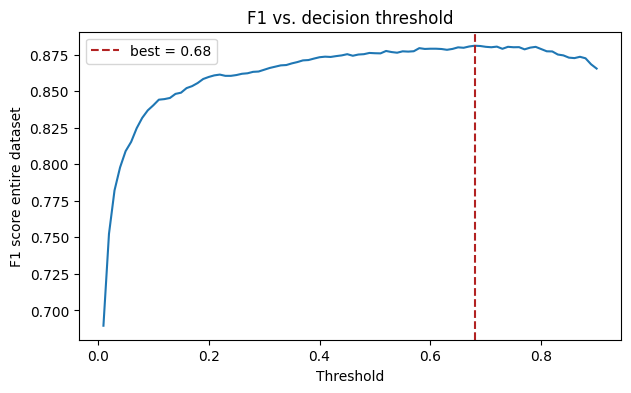

In [79]:
from sklearn.metrics import f1_score, classification_report

thresholds = np.arange(0.01, 0.91, 0.01)
f1_scores = [f1_score(y_full, (oof_full >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Best threshold: {best_threshold:.2f}  (dataset F1 = {best_f1:.4f})")
print()
print("Full-dataset OOF classification report at this threshold:")
print(classification_report(y_full, (oof_full >= best_threshold).astype(int), digits=4))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="firebrick", linestyle="--", label=f"best = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 score entire dataset")
plt.title("F1 vs. decision threshold")
plt.legend()
plt.show()


In [80]:
submission_binary = sample_submission.copy()
submission_binary[id_col] = test_fe["ID"].values
submission_binary[pred_col] = (test_pred_blend >= best_threshold).astype(int)

print("Predicted default rate in test:", submission_binary[pred_col].mean().round(4))
print("Actual default rate in train:  ", y_full.mean().round(4))
print("Rows forced to 0 by is_relevant:", (~relevant_test_mask).sum(), "/", len(test_fe))

binary_out_path = r"C:\Users\HP\Downloads\african-credit-scoring-challenge20241203-14702-1yayxml\submission_2.csv"
submission_binary.to_csv(binary_out_path, index=False)
print("\nSaved:", binary_out_path)

submission_binary.head()


Predicted default rate in test: 0.035
Actual default rate in train:   0.0183
Rows forced to 0 by is_relevant: 15562 / 18594

Saved: C:\Users\HP\Downloads\african-credit-scoring-challenge20241203-14702-1yayxml\submission_2.csv


,ID,target
0,ID_6083142641251804,0
1,ID_6083212266267278,0
2,ID_7154223193267278,0
3,ID_7154238379267278,0
4,ID_7154279438267278,0
